# SlotSaver — Level 2a: Calibration & the cost-sensitive call threshold

**The question this notebook answers:** when the model says "this patient has a
40% no-show risk", is that number *true*? And once it is true, exactly which
patients are worth a staff call?

Level 1 only needed a **ranking** (call the top 20). Level 2 needs honest
**probabilities**, because the intervention decision is economic:

> EV(call) = p × success_rate × revenue_per_slot − cost_per_call

Plug a distorted p into that formula and every decision downstream is wrong.

In [3]:
import sys
if "google.colab" in sys.modules:          # this cell does nothing on your PC
    !unzip -q -o slotsaver.zip
    %cd slotsaver
    !mkdir -p data
    !cp /content/noshowappointments*.csv data/KaggleV2-May-2016.csv
    %pip install -q lightgbm

/content/slotsaver


In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lightgbm import LGBMClassifier
from sklearn.metrics import brier_score_loss, roc_auc_score

from src.data import load_or_synthesize
from src.features import CATEGORICAL, FEATURES, LABEL, add_history_features
from src.calibrate import (ev_call_threshold, expected_calibration_error,
                           fit_isotonic, reliability_table, risk_tiers,
                           three_way_temporal_split)

pd.set_option("display.max_columns", 40)

## 1. Data and the three-way temporal split

New rule for calibration: the calibrator must be fit on data the model never
trained on. So we carve a **calibration window** out of the *end* of the
training period. The test window is identical to Level 1's — every number
here is directly comparable to the Level 1 table.

In [5]:
df, is_real = load_or_synthesize("data/KaggleV2-May-2016.csv")
df = add_history_features(df)
train, cal, test = three_way_temporal_split(df, cal_frac=0.15, test_frac=0.25)

def to_xy(d):
    X = d[FEATURES].copy()
    for c in CATEGORICAL:
        X[c] = X[c].astype("category")
    return X, d[LABEL]

X_train, y_train = to_xy(train)
X_cal, y_cal = to_xy(cal)
X_test, y_test = to_xy(test)

clean(): dropped 6 bad-age rows, 5 negative-lead-time rows (110527 -> 110516)
three_way_temporal_split(): train=67357 (to 2016-05-20)  cal=12431 (2016-05-24..2016-05-30)  test=30728 (from 2016-05-31)


## 2. Exhibit A: the Level 1 model's probabilities are broken

`class_weight="balanced"` tells LightGBM to pretend no-shows are as common as
shows (50/50 instead of 20/80). That sharpens the ranking objective but
inflates every probability. Watch:

In [6]:
lgbm_balanced = LGBMClassifier(n_estimators=400, learning_rate=0.05, num_leaves=31,
                               class_weight="balanced", random_state=42, verbose=-1)
lgbm_balanced.fit(X_train, y_train)
p_balanced = lgbm_balanced.predict_proba(X_test)[:, 1]

print(f"Actual no-show rate in test window : {y_test.mean():.3f}")
print(f"Mean 'probability' (balanced model): {p_balanced.mean():.3f}  <- inflated")
reliability_table(y_test, p_balanced)

Actual no-show rate in test window : 0.184
Mean 'probability' (balanced model): 0.423  <- inflated


,bin,mean_predicted,actual_rate,count
0,0.0–0.1,0.059814,0.023189,4528
1,0.1–0.2,0.142109,0.040190,4205
2,0.2–0.3,0.246470,0.084251,1816
3,0.3–0.4,0.354162,0.156019,2160
4,0.4–0.5,0.454606,0.196843,4054
5,0.5–0.6,0.549786,0.238411,5285
6,0.6–0.7,0.646768,0.293004,4488
7,0.7–0.8,0.744597,0.327464,2953
8,0.8–0.9,0.841119,0.424571,1107
9,0.9–1.0,0.921938,0.568182,132


## 3. Two fixes

**Fix 1 — retrain without class_weight.** LightGBM optimizes log-loss, which
naturally targets true probabilities. (Does removing it hurt the ranking?
Check the AUC below — spoiler: barely, trees mostly reorder thresholds.)

**Fix 2 — isotonic calibration.** Keep any model you like, then learn a
monotonic score→probability mapping on the calibration window. Monotonic
means the ranking is *exactly* preserved; only the labels on the scores change.

We do both: plain model + isotonic on top.

In [7]:
lgbm_plain = LGBMClassifier(n_estimators=400, learning_rate=0.05, num_leaves=31,
                            random_state=42, verbose=-1)
lgbm_plain.fit(X_train, y_train)

p_cal_raw = lgbm_plain.predict_proba(X_cal)[:, 1]   # scores on calibration window
iso = fit_isotonic(p_cal_raw, y_cal)                 # fit mapping there...

p_plain = lgbm_plain.predict_proba(X_test)[:, 1]
p_iso = iso.predict(p_plain)                         # ...apply to test scores

## 4. Scoreboard

- **Brier score**: mean squared error of probabilities (lower = better).
- **ECE**: average predicted-vs-actual gap across bins (< 0.02 is good).
- **ROC-AUC**: shown to prove calibration didn't damage the ranking.

In [8]:
rows = []
for name, p in [("balanced (Level 1)", p_balanced),
                ("plain", p_plain),
                ("plain + isotonic", p_iso)]:
    rows.append({
        "model": name,
        "roc_auc": round(roc_auc_score(y_test, p), 3),
        "brier": round(brier_score_loss(y_test, p), 4),
        "ece": round(expected_calibration_error(y_test, p), 4),
        "mean_p": round(float(np.mean(p)), 3),
    })
scoreboard = pd.DataFrame(rows).set_index("model")
scoreboard

,roc_auc,brier,ece,mean_p
model,,,,
balanced (Level 1),0.725,0.2091,0.2387,0.423
plain,0.727,0.1396,0.0354,0.217
plain + isotonic,0.726,0.1358,0.0151,0.198


Expected pattern: all three AUCs nearly identical (ranking preserved), but ECE
collapses from the balanced model to the isotonic one, and mean_p lands next
to the true base rate.

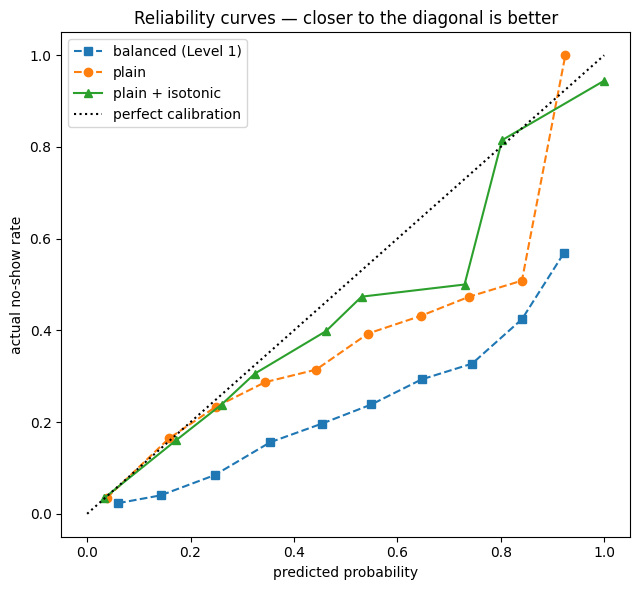

In [9]:
fig, ax = plt.subplots(figsize=(6.5, 6))
for name, p, style in [("balanced (Level 1)", p_balanced, "s--"),
                       ("plain", p_plain, "o--"),
                       ("plain + isotonic", p_iso, "^-")]:
    t = reliability_table(y_test, p)
    ax.plot(t["mean_predicted"], t["actual_rate"], style, label=name)
ax.plot([0, 1], [0, 1], "k:", label="perfect calibration")
ax.set_xlabel("predicted probability")
ax.set_ylabel("actual no-show rate")
ax.set_title("Reliability curves — closer to the diagonal is better")
ax.legend()
plt.tight_layout()
plt.show()

## 5. The cost-sensitive threshold — economics, not statistics

Call a patient only when the expected value is positive:

> p × success × revenue − cost > 0  ⟹  **p\* = cost / (success × revenue)**

With the default assumptions ($5 call, 30% success, $200 slot):
p\* = 5 / 60 ≈ **0.083**. Almost every plausible target clears that bar —
at these economics, **staff capacity is the binding constraint, not the
threshold**. But watch what happens if a call really costs $30 of staff time:

In [10]:
for cost in [5, 15, 30]:
    thr = ev_call_threshold(cost_per_call=cost)
    n_worth = int((p_iso > thr).sum())
    print(f"cost/call ${cost:>2}: threshold p* = {thr:.3f} -> "
          f"{n_worth} of {len(p_iso)} test appointments worth calling")

cost/call $ 5: threshold p* = 0.083 -> 21306 of 30728 test appointments worth calling
cost/call $15: threshold p* = 0.250 -> 12900 of 30728 test appointments worth calling
cost/call $30: threshold p* = 0.500 -> 403 of 30728 test appointments worth calling


This is the sentence for interviews: *"the threshold comes from the cost
model, the probability comes from the calibrated classifier, and the two are
independent — you can re-price interventions without retraining."*

## 6. Risk tiers — connecting probabilities to the product

The deep-dive product design has tiered interventions. Now that probabilities
are honest, tiers are just probability bands:

In [11]:
test_scored = test.copy()
test_scored["p_noshow"] = p_iso
test_scored["tier"] = risk_tiers(p_iso).values

per_day = (test_scored.groupby([test_scored["appointment_day"].dt.date, "tier"],
                               observed=True).size().unstack(fill_value=0))
print("Average appointments per clinic day, by intervention tier:")
per_day.mean().round(0).astype(int)

Average appointments per clinic day, by intervention tier:


,0
tier,
extra_reminder,2336
sms_only,1583
staff_call,470


## 7. Conclusions — calibration and cost-sensitive thresholds

* **Inaccuracy of Level 1 Probabilities**
* The Level 1 model's probabilities were significantly inflated because the model was trained with a "balanced" class weight, which falsely assumes no-shows are as common as shows.


* We know these probabilities were wrong because the mean predicted probability for the balanced model was heavily inflated compared to the actual base rate of the test window.


* Furthermore, the Expected Calibration Error (ECE) for the balanced model was high, but the error collapses significantly when switching to the isotonic model.


* The reliability plot visually confirms this inflation, as the curve for the balanced Level 1 model deviates far from the diagonal line that represents perfect calibration.




* **Impact of Calibration on Ranking Power**
* Calibrating the model did not damage its ranking power.


* The ROC-AUC scores remained nearly identical across all three models (balanced, plain, and plain + isotonic).


* Because isotonic calibration applies a monotonic mapping, the exact ranking of the patients is preserved, and only the probability labels attached to those scores are adjusted.




* **The 0.083 Cost-Sensitive Call Threshold**
* The call threshold sits at 0.083 rather than 0.5 because the intervention decision relies on economics rather than statistics.


* A patient is worth calling as soon as the expected value of the call becomes positive, which is dictated by the formula:
$p^* = \frac{\text{cost}}{\text{success} \times \text{revenue}}$.


* Plugging in the default assumptions—a $5 cost per call, a 30% success rate, and $200 in revenue per slot—results in a threshold of 0.083.


* This threshold would rise if the intervention costs more; for instance, if staff time makes a call cost $30 instead of $5, the required probability of a no-show to justify that call would increase.

* **Tier sizes vs capacity — the operational finding.**
* With boundaries at 0.15/0.35, the staff_call tier holds ~470 appointments per clinic day against a realistic capacity of ~20 calls — honest probabilities alone don't make a workable plan.
* The fix is operational, not statistical: rank by probability *within* the tier and call the top 20, or move the boundary until the tier matches staffing. Calibration makes that boundary trustworthy; the clinic chooses where it sits.

**Limitations:** isotonic is fit on one calibration window — if the score
distribution drifts, recalibrate; tier boundaries (0.15 / 0.35) are product
guesses to tune with a real clinic — note the staff_call tier currently holds
~470 appointments/day against a 20-call/day capacity.

**Next (Level 2b):** SHAP per-patient explanations + the Streamlit call-list
dashboard that shows tier, probability, and "why" for each appointment.
